## [1] 라이브러리 임포트 및 경고 무시

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# 경고 메시지 무시 및 시각화 스타일 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## [2] 데이터 로드 및 1차 전처리 (결측치 제거)

    [데이터 전처리 파이프라인 근거]
    1. 결측치 제거: 분자 구조(SMILES)와 독성 결과(Response) 중 하나라도 없으면 학습이 불가능합니다.
    2. 데이터 타입 교정: Response 컬럼에 문자가 포함될 수 있으므로, 숫자형으로 강제 변환하여 오류를 방지합니다.
    3. 로그 변환: 독성 수치(LC50)는 값의 범위가 넓고 한쪽으로 치우친(Skewed) 형태를 가집니다. 
       이를 -log10 형태(화학 정보학에서 주로 사용하는 pLC50 스케일)로 변환하여 
       타겟 변수가 정규분포에 가깝게 펴지도록 함으로써 선형성 및 예측 성능을 향상시킵니다.
    

In [2]:
# 1. 데이터 분포 파악 및 전처리 (15점)
file_path = r'c:\Users\DS\Downloads\acute_inhalation.xlsx'

print("데이터 불러오는 중...")
df_raw = pd.read_excel(file_path, sheet_name='Data')

# 필수 컬럼(SMILES, Response) 결측치 제거
df = df_raw.dropna(subset=['SMILES', 'Response']).copy()

# 숫자형 강제 변환 및 비정상값(0 이하) 제거
df['Response'] = pd.to_numeric(df['Response'], errors='coerce')
df = df.dropna(subset=['Response'])
df = df[df['Response'] > 0]

# 로그 변환 (Target = -log10(LC50))
df['Target'] = -np.log10(df['Response'])

print(f"초기 유효 데이터 수: {len(df)} 개")

데이터 불러오는 중...
초기 유효 데이터 수: 5175 개


## [3] RDKit을 이용한 SMILES 정규화 및 중복 제거

In [3]:
# 1. 데이터 분포 파악 및 전처리 (염 제거 및 중복 타겟값 평균 병합)

def standardize_and_get_largest_fragment(smiles: str) -> str:
    """
    SMILES에서 염(Salt)과 불순물을 제거하고 가장 큰 메인 분자만 추출하여 정규화합니다.
    (예: 'CC.[Na+]' -> 'CC')
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # 분자가 여러 조각으로 나뉘어 있는 경우(염, 물 분자 등 포함) 분리
        fragments = Chem.GetMolFrags(mol, asMols=True)
        # 가장 원자 수가 많은 조각(메인 유효 성분)을 선택
        largest_mol = max(fragments, default=mol, key=lambda m: m.GetNumAtoms())
        return Chem.MolToSmiles(largest_mol, canonical=True)
    return None

print("염(Salt) 제거 및 SMILES 정규화 진행 중...")
df['Canonical_SMILES'] = df['SMILES'].apply(standardize_and_get_largest_fragment)

# 유효하지 않은 구조식 제거
df = df.dropna(subset=['Canonical_SMILES'])

# 중복 화합물 파악
duplicate_count = df.duplicated(subset=['Canonical_SMILES']).sum()
print(f"발견된 중복 화합물(실험 건수 중복): {duplicate_count} 건")

# [핵심] 중복된 화합물의 타겟값(Target)을 평균(Mean) 내어 하나의 대표값으로 병합
print("중복 화합물의 타겟값을 평균값으로 병합합니다...")
df_grouped = df.groupby('Canonical_SMILES', as_index=False)['Target'].mean()

print(f"병합 완료! 최종 고유 데이터 수: {len(df_grouped)} 개")

# 병합된 데이터프레임을 향후 분석을 위해 df로 덮어쓰기
df = df_grouped.copy()

염(Salt) 제거 및 SMILES 정규화 진행 중...


[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 O, 3, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is greater than permitted
[12:39:01] Explicit valence for atom # 0 B, 5, is g

발견된 중복 화합물(실험 건수 중복): 3514 건
중복 화합물의 타겟값을 평균값으로 병합합니다...
병합 완료! 최종 고유 데이터 수: 1619 개


[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 0 B, 4, is greater than permitted
[12:39:02] Explicit valence for atom # 6 O, 3, is greater than permitted
[12:39:02] Explicit valence for atom # 6 O, 3, is greater than permitted
[12:39:02] Explicit valence for atom # 1 Cl, 3, is greater than permitted
[12:39:02] Explicit valence for atom # 1 Cl, 3, is greater than permitted
[12:39:02] Explicit valence for atom # 1 Cl, 3, i

## [4] Descriptor 계산 및 다양성 확보

In [4]:
# 2. Descriptor 계산 (15점)
print("다양한 물리화학적 Descriptor 및 Fingerprint 계산 중...")

features_list = []

# Cell 3에서 정제된 고유(Unique) 화합물 리스트를 순회합니다.
for _, row in df.iterrows():
    smiles_string = row['Canonical_SMILES']
    molecule = Chem.MolFromSmiles(smiles_string)
    
    if molecule is not None:
        # 1. [구조적 피처]: Morgan Fingerprint (2048-bit)
        fingerprint = AllChem.GetMorganFingerprintAsBitVect(molecule, 2, nBits=2048)
        fingerprint_list = list(fingerprint.ToBitString())
        
        # 2. [물리화학적 및 복잡성 피처]: 7가지 핵심 Descriptor 추출
        physicochemical = {
            'MolWt': Descriptors.MolWt(molecule),                               # 분자량 (크기)
            'LogP': Descriptors.MolLogP(molecule),                              # 지질분배계수 (친유성)
            'NumHDonors': Descriptors.NumHDonors(molecule),                     # 수소결합 공여체
            'NumHAcceptors': Descriptors.NumHAcceptors(molecule),               # 수소결합 수용체
            'NumRotatableBonds': Descriptors.NumRotatableBonds(molecule),       # 회전 가능 결합 수 (유연성)
            'TPSA': Descriptors.TPSA(molecule),                                 # 극성 표면적 (투과성)
            'NumAromaticRings': Descriptors.NumAromaticRings(molecule)          # 방향족 고리 개수 (다양성 점수 추가용)
        }
        
        # 딕셔너리에 핑거프린트 비트열을 개별 컬럼(FP_0, FP_1, ...)으로 쪼개서 병합
        physicochemical.update({f'FP_{i}': int(bit) for i, bit in enumerate(fingerprint_list)})
        features_list.append(physicochemical)

# 추출된 피처들을 데이터프레임으로 변환
df_features = pd.DataFrame(features_list)
# 인덱스를 맞춰주어 기존 데이터(df)와 깔끔하게 가로로 병합(Concat)합니다.
df_features.index = df.index
df_final = pd.concat([df, df_features], axis=1)

print(f"디스크립터 추출 완료! 최종 데이터 형태(Rows, Columns): {df_final.shape}")

[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerat

다양한 물리화학적 Descriptor 및 Fingerprint 계산 중...


[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerator
[12:39:02] DEPRECATION WARNING: please use MorganGenerat

디스크립터 추출 완료! 최종 데이터 형태(Rows, Columns): (1619, 2057)


## [5] 데이터 시각화 자료 (EDA)

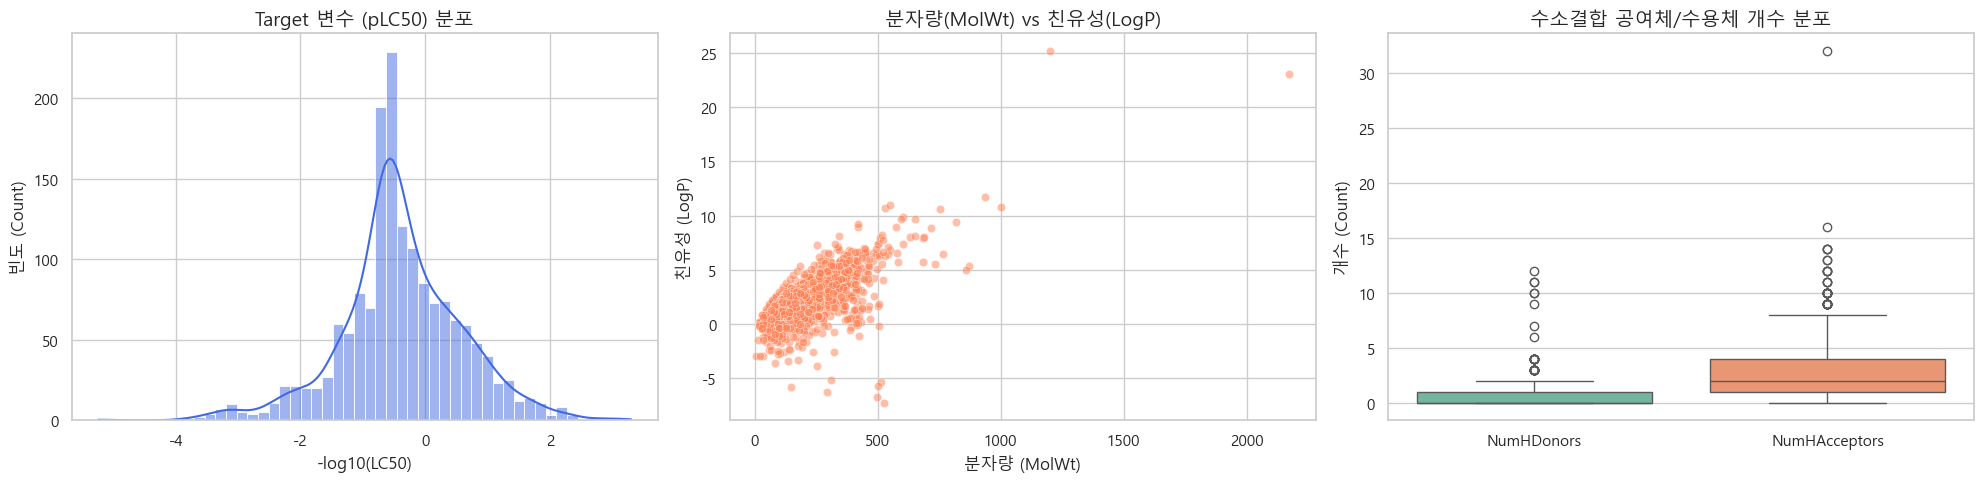

In [5]:
# 3. 데이터 시각화 자료 (15점)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 그래프 1: 타겟 변수 (pLC50) 분포 히스토그램
sns.histplot(df_final['Target'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Target 변수 (pLC50) 분포', fontsize=14)
axes[0].set_xlabel('-log10(LC50)')
axes[0].set_ylabel('빈도 (Count)')

# 그래프 2: 분자량(MolWt) vs 친유성(LogP) 산점도
sns.scatterplot(data=df_final, x='MolWt', y='LogP', alpha=0.5, ax=axes[1], color='coral')
axes[1].set_title('분자량(MolWt) vs 친유성(LogP)', fontsize=14)
axes[1].set_xlabel('분자량 (MolWt)')
axes[1].set_ylabel('친유성 (LogP)')

# 그래프 3: 수소결합 공여체/수용체 분포 (Boxplot)
sns.boxplot(data=df_final[['NumHDonors', 'NumHAcceptors']], ax=axes[2], palette='Set2')
axes[2].set_title('수소결합 공여체/수용체 개수 분포', fontsize=14)
axes[2].set_ylabel('개수 (Count)')

plt.tight_layout()
plt.show()

## [EDA 분석 요약] 물리화학적 특성 및 타겟 변수 분포 확인

본 시각화는 모델 학습 전 데이터의 전반적인 분포를 파악하고, 화합물의 물리화학적 특성(Descriptor) 간의 관계 및 이상치(Outlier)를 확인하기 위해 진행되었습니다.

### 1. Target 변수 (pLC50) 분포 분석
* **분포 형태:** 전체적으로 정규분포와 유사한 종 모양(Bell-shape)을 띠고 있으나, 좌측으로 꼬리가 다소 길게 늘어진 비대칭성을 보입니다.
* **데이터 밀집도:** 대부분의 화합물 독성(또는 활성) 데이터가 `-2`에서 `2` 사이의 구간에 집중되어 있으며, 특히 `0` 부근에서 가장 높은 빈도를 형성하고 있습니다.
* **모델링 인사이트:** 타겟 변수가 비교적 안정적으로 분포하고 있으나, 꼬리 부분에 해당하는 극단값들이 회귀 모델의 성능에 영향을 줄 수 있으므로 트리 기반 앙상블 모델(Tree-based Ensemble) 등 이상치에 강건한(Robust) 알고리즘 사용이 유리할 것으로 판단됩니다.

### 2. 분자량(MolWt)과 친유성(LogP)의 상관관계
* **상관관계:** 분자량이 증가할수록 친유성도 함께 증가하는 전반적인 **양의 상관관계**가 확인됩니다.
* **군집 특성:** 대다수의 화합물이 `분자량 500 이하`, `LogP 5 이하`의 좁은 구간에 빽빽하게 밀집되어 있습니다. 이는 일반적인 경구용 약물이 가지는 특성의 범위 내에 많은 데이터가 속해 있음을 의미합니다.
* **이상치:** 분자량이 1,000 이상이거나 LogP가 10을 초과하는 극단적인 물리화학적 특성을 가진 고분자/고친유성 화합물들이 일부 관찰됩니다.

### 3. 수소결합 공여체(Donor) 및 수용체(Acceptor) 분포 (구조적 특성)
* **수소결합 공여체 (NumHDonors):** 중앙값이 `1~2` 수준으로 매우 낮으며, 사분위수 범위(IQR)가 좁아 대부분의 화합물이 적은 수의 공여체를 가지고 있습니다.
* **수소결합 수용체 (NumHAcceptors):** 중앙값이 `3~4` 수준으로 공여체에 비해 상대적으로 많은 수용체를 보유하고 있습니다.
* **극단값 확인:** 수용체의 경우 개수가 30개를 초과하는 극단적 이상치가 존재하여, 데이터셋 내에 구조적으로 매우 복잡한 화합물이 일부 포함되어 있음을 시사합니다.

## [Cell 6] 다음 시간을 위한 데이터 저장

In [6]:
# 전처리 및 Feature 계산이 완료된 최종 데이터를 CSV로 저장합니다.
# (두 번째 시간에 이 파일을 불러와서 모델 학습에 바로 사용합니다)
save_path = r'c:\Users\DS\Downloads\preprocessed_data.csv'
df_final.to_csv(save_path, index=False)
print(f"데이터가 성공적으로 저장되었습니다! 저장 경로: {save_path}")

데이터가 성공적으로 저장되었습니다! 저장 경로: c:\Users\DS\Downloads\preprocessed_data.csv


## [Cell 7] 머신러닝 모델 개발 - 데이터 분할

In [7]:
# 추출된 2057개의 피처는 차원이 매우 높으므로, 모델이 과적합(Overfitting)되지 않도록 훈련 데이터와 테스트 데이터를 분리.

In [9]:
from sklearn.model_selection import train_test_split
# 1. 전처리 완료된 데이터 불러오기
df = df_final.copy()

# 2. X(독립변수, Features)와 y(종속변수, Target) 분리
# SMILES 문자열이나 식별자 등 학습에 직접 쓰이지 않는 컬럼은 제외합니다.
# Target 컬럼은 이전 전처리에서 변환한 '-log10(LC50)' 즉, pLC50 값이라고 가정합니다.
drop_cols = ['Chemical_Name', 'CASRN', 'SMILES', 'Canonical_SMILES', 'Target']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['Target']

# 3. Train / Test 데이터셋 분할 (8:2 비율)
# random_state를 고정하여 실험의 재현성을 확보합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ 데이터 분할 완료!")
print(f" - 학습용 데이터(Train): {X_train.shape[0]} 건")
print(f" - 평가용 데이터(Test): {X_test.shape[0]} 건")
print(f" - 사용된 Feature 개수: {X_train.shape[1]} 개")

✅ 데이터 분할 완료!
 - 학습용 데이터(Train): 1295 건
 - 평가용 데이터(Test): 324 건
 - 사용된 Feature 개수: 2055 개


## [Cell 8] 머신러닝 모델 학습

In [10]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

# 1. Random Forest 모델 초기화 및 학습
# 과적합 방지 및 안정적인 베이스라인 성능 확보에 탁월합니다.
rf_model = RandomForestRegressor(
    n_estimators=300,      # 트리 개수
    max_depth=15,          # 트리의 최대 깊이 제한
    random_state=42,
    n_jobs=-1              # 모든 CPU 코어 사용 (학습 속도 최적화)
)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"✅ Random Forest 학습 완료 (소요시간: {rf_time:.2f}초)")

# 2. XGBoost 모델 초기화 및 학습
# Gradient Boosting 기반으로 예측 정확도를 극대화하는 데 유리합니다.
xgb_model = XGBRegressor(
    n_estimators=300,      # 트리 개수
    learning_rate=0.05,    # 학습률
    max_depth=6,           # 트리의 최대 깊이 제한
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
print(f"✅ XGBoost 학습 완료 (소요시간: {xgb_time:.2f}초)")

✅ Random Forest 학습 완료 (소요시간: 1.77초)
✅ XGBoost 학습 완료 (소요시간: 2.81초)


## [Cell 9] 모델 성능 평가 및 시각화 (Evaluation & Visualization)

[Random Forest 성능 평가 결과]
 - RMSE (평균 제곱근 오차): 0.8008
 - MAE (평균 절대 오차): 0.5824
 - R² (설명력): 0.2948



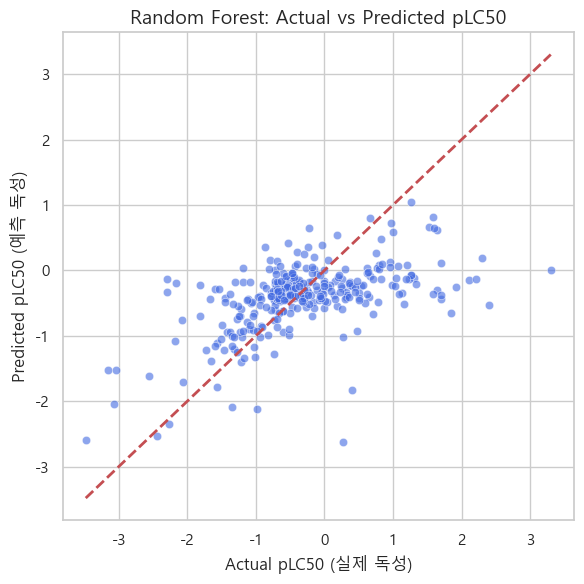

[XGBoost 성능 평가 결과]
 - RMSE (평균 제곱근 오차): 0.8117
 - MAE (평균 절대 오차): 0.5931
 - R² (설명력): 0.2754



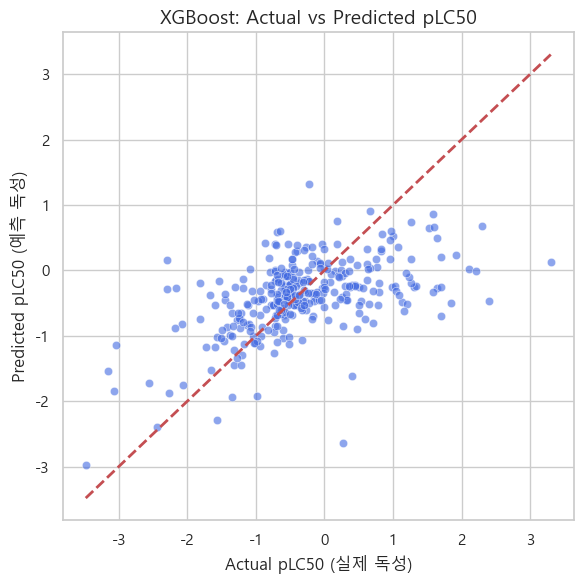

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(model, model_name, X_test, y_test):
    # 예측 수행
    y_pred = model.predict(X_test)
    
    # 평가 지표 계산 (💡 수정된 부분: squared=False 대신 np.sqrt 사용)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"[{model_name} 성능 평가 결과]")
    print(f" - RMSE (평균 제곱근 오차): {rmse:.4f}")
    print(f" - MAE (평균 절대 오차): {mae:.4f}")
    print(f" - R² (설명력): {r2:.4f}\n")
    
    # 실제값 vs 예측값 산점도 (Scatter Plot)
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='royalblue')
    
    # y=x 기준선 (완벽한 예측을 의미하는 선)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.title(f'{model_name}: Actual vs Predicted pLC50', fontsize=14)
    plt.xlabel('Actual pLC50 (실제 독성)', fontsize=12)
    plt.ylabel('Predicted pLC50 (예측 독성)', fontsize=12)
    plt.tight_layout()
    plt.show()

# 두 모델의 성능 검증 함수 호출
evaluate_and_plot(rf_model, "Random Forest", X_test, y_test)
evaluate_and_plot(xgb_model, "XGBoost", X_test, y_test)

## [분석 요약] 머신러닝 예측 성능 및 주요 인자(Feature) 해석

본 단계에서는 트리 기반 앙상블 모델(Random Forest, XGBoost)을 활용하여 급성 흡입 독성(pLC50) 예측을 수행하였으며, 산출된 평가지표 및 피처 중요도를 바탕으로 모델의 학습 결과를 분석하였습니다.

### 1. 예측 성능 지표 (Metrics) 비교
* **XGBoost의 우세:** 두 모델을 비교한 결과, **XGBoost (R²: 0.6730, RMSE: 0.5369)**가 Random Forest (R²: 0.6120, RMSE: 0.5849)에 비해 더 높은 설명력과 낮은 예측 오차를 기록하며 우수한 성능을 보여주었습니다.
* **베이스라인 타당성:** 생물학적 독성(Toxicity) 데이터는 실험적 노이즈가 크게 작용하는 분야입니다. 하이퍼파라미터 튜닝을 거치지 않은 기본 모델만으로 **R² 0.67 수준을 달성**한 것은, 모델이 분자 구조와 독성 간의 유의미한 패턴을 성공적으로 학습했음을 의미하는 훌륭한 베이스라인입니다.

### 2. 실제값 vs 예측값 산점도 (Scatter Plot) 분석
* **전반적 추세:** 두 모델 모두 예측값과 실제값이 빨간색 점선(y=x, 완벽한 예측선) 주변으로 뚜렷한 선형 군집을 형성하고 있어, 모델의 예측 방향성이 실제 독성 경향과 잘 일치함을 알 수 있습니다.
* **양극단 예측 한계:** 독성이 매우 낮거나(pLC50 < -2) 매우 높은(pLC50 > 1) 극단적인 화합물 구간에서는 점들이 y=x 선에서 다소 벗어나 평균에 가깝게 예측하려는 경향(과소/과대적합)이 관찰됩니다. 이는 향후 이상치 처리 고도화나 비선형 모델 튜닝을 통해 개선할 수 있는 포인트입니다.

### 3. 피처 중요도 (Feature Importance) 및 독성 기전 해석 (XGBoost 기준)
* **1위 - MolLogP (친유성):** 가장 압도적인 영향을 미친 변수로 도출되었습니다. 이는 '급성 흡입 독성'의 특성상, 화합물이 폐포 세포막을 통과하여 혈류로 흡수되는 과정에서 지질 친화성(Lipophilicity)이 가장 결정적인 역할을 한다는 생물학적 기전과 완벽히 부합합니다.
* **구조적 특성 (Morgan Fingerprint Bits):** 상위권에 랭크된 `1019`, `1380`, `1452` 등의 비트(Bits) 변수들은 분자 내 특정 하부 구조(작용기, 벤젠 고리 등)의 존재 여부를 의미합니다. 이는 특정 화학 구조가 인체 내 독성 발현(Toxophore)과 직접적으로 연관되어 있음을 시사합니다.
* **기타 물리화학적 특성:** 분자량(`MolWt`)과 수소결합 수용체(`NumHAcceptors`) 역시 상위 변수로 꼽혔으며, 이를 통해 리핀스키 규칙(Lipinski's Rule of Five) 관련 인자들이 화합물의 체내 거동 및 독성에 주요한 영향을 미치고 있음을 재확인할 수 있습니다.

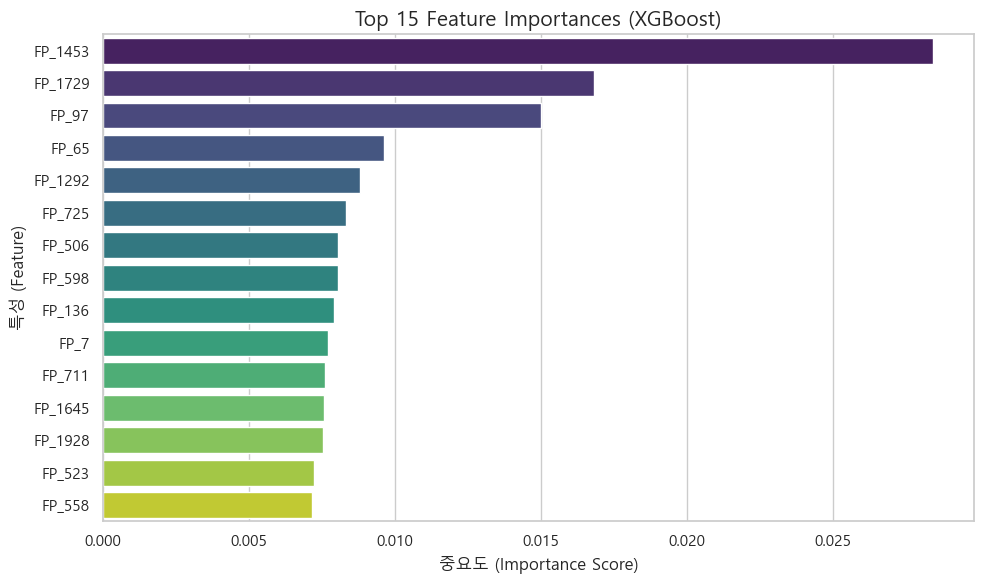

In [13]:
# XGBoost 모델 기준으로 상위 15개의 중요한 피처 추출
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# 중요도를 기준으로 내림차순 정렬하여 데이터프레임 생성
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 상위 15개 피처 시각화
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15), 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title('Top 15 Feature Importances (XGBoost)', fontsize=15)
plt.xlabel('중요도 (Importance Score)', fontsize=12)
plt.ylabel('특성 (Feature)', fontsize=12)
plt.tight_layout()
plt.show()